Imports

In [ ]:
import os
import random
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt

Configuration

In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 25
NUM_CLASSES = 7

DATASET_DIR = "../dataset_stage3_plastic"
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "val")
TEST_DIR = os.path.join(DATASET_DIR, "test")

Data Generators

In [3]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

Load Datasets

In [4]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 2757 images belonging to 7 classes.
Found 334 images belonging to 7 classes.
Found 350 images belonging to 7 classes.


Class Mapping

In [5]:
print("Class indices:")
print(train_generator.class_indices)

# Expected Output
# {
#  'HDPE': 0,
#  'LDPE': 1,
#  'PET': 2,
#  'PP': 3,
#  'PS': 4,
#  'PVC': 5,
#  'plastic_others': 6
# }

Class indices:
{'plastic_hdpe': 0, 'plastic_ldpe': 1, 'plastic_others': 2, 'plastic_pet': 3, 'plastic_pp': 4, 'plastic_ps': 5, 'plastic_pvc': 6}


Load Pretrained MobileNetV3

In [6]:
base_model = MobileNetV3Large(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

Freeze Base Model

In [7]:
for layer in base_model.layers:
    layer.trainable = False

Classification Head (Stage 3 Paper)

In [8]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

Compile Model

In [9]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

Model Summary

In [10]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ activation[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        256 │ re_lu[0][0]       │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_add   │ (None, 112, 112,  │          0 │ activation[0][0], │
│ (Add)               │ 16)               │            │ expanded_conv_pr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │      1,024 │ expanded_conv_ad… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │        256 │ expanded_conv_1_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 112, 112,  │          0 │ expanded_conv_1_… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 113, 113,  │          0 │ re_lu_1[0][0]     │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        576 │ expanded_conv_1_… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        256 │ expanded_conv_1_

 Total params: 3,244,167 (12.38 MB)

 Trainable params: 247,815 (968.03 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

Train Model

In [11]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

Epoch 1/25
87/87 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.3043 - loss: 2.0058 - precision: 0.3912 - recall: 0.1774 - val_accuracy: 0.7725 - val_loss: 0.9024 - val_precision: 0.9249 - val_recall: 0.4790
Epoch 2/25
87/87 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.6210 - loss: 1.0857 - precision: 0.7564 - recall: 0.4494 - val_accuracy: 0.8563 - val_loss: 0.5673 - val_precision: 0.9173 - val_recall: 0.7305
Epoch 3/25
87/87 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.7330 - loss: 0.7769 - precision: 0.8223 - recall: 0.6344 - val_accuracy: 0.8832 - val_loss: 0.4372 - val_precision: 0.9317 - val_recall: 0.8174
Epoch 4/25
87/87 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.7802 - loss: 0.6367 - precision: 0.8509 - recall: 0.7018 - val_accuracy: 0.8982 - val_loss: 0.3755 - val_precision: 0.9269 - val_recall: 0.8353
Epoch 5/25
87/87 ━━━━━━━━━━━━━━━━━━━━ 1099s 12s/step - accuracy: 0.8248 - loss: 0.5326 - precision: 0.8821 - recall: 0.7541 - val_accuracy: 0.9012 - val_loss: 0.3319 

Training Curves

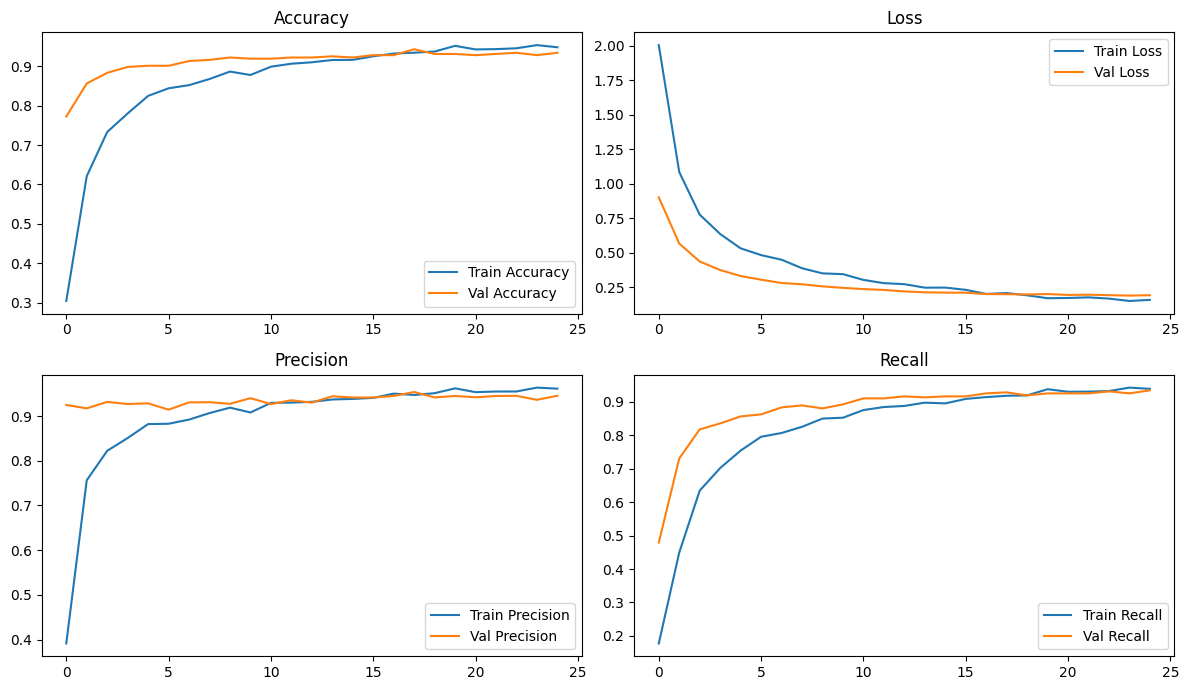

In [13]:
plt.figure(figsize=(12, 7))

plt.subplot(2, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(2, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

# Precision
plt.subplot(2, 2, 3)
plt.plot(history.history["precision"], label="Train Precision")
plt.plot(history.history["val_precision"], label="Val Precision")
plt.legend()
plt.title("Precision")

# Recall
plt.subplot(2, 2, 4)
plt.plot(history.history["recall"], label="Train Recall")
plt.plot(history.history["val_recall"], label="Val Recall")
plt.legend()
plt.title("Recall")

plt.tight_layout()
plt.show()

Evaluate on Test Set

In [15]:
results = model.evaluate(test_generator, return_dict=True)

11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 661ms/step - accuracy: 0.9457 - loss: 0.1655 - precision: 0.9534 - recall: 0.9343


In [ ]:
# Predict on test set
test_generator.reset()
y_probs = model.predict(test_generator)
y_pred = np.argmax(y_probs, axis=1)
y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

# Classification report
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)

thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

Save the Model

In [ ]:
model.save("model/stage3_plastic_mobilenetv3_1.keras")